# Simulation-Based Inference for a Linear Regression Model

This notebook combines the linear-regression example with the experiments exploring how the inference results change when the data, noise level, prior, and SBI training settings are varied.

We compare three approaches:

- **Analytic Bayesian inference** using the closed-form linear-regression posterior.
- **MCMC** using PyMC.
- **Simulation-Based Inference (SBI)** using neural posterior estimation.

The main goal is to check how well SBI recovers the posterior and how sensitive the inference is to the experimental setup.

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sbi import utils as sbi_utils
from sbi import inference as sbi_inference
from sbi.inference import simulate_for_sbi
from sbi.analysis import plot_summary

import pymc as pm

## Problem setup

We consider a simple linear model
$$y = mx + c + \epsilon$$

where \(m\) is the slope, \(c\) is the intercept, and the observational noise is Gaussian.

The goal is to infer the two parameters \((m,c)\) from simulated observations. The known parameter values are used only to generate the synthetic observations, so that the inferred posterior can be compared with the true values.

In [ ]:
def setup_experiment(
    theta_true=torch.tensor([3.6, -4.4]),
    sigma_noise=0.1,
    n_grid=20,
    x_domain=(-1.0, 1.0),
    prior_bounds=(-10.0, 10.0),
):
    device = torch.device("cpu")
    torch.manual_seed(32)

    x_grid = torch.linspace(x_domain[0], x_domain[1], n_grid).to(device)

    prior_low = torch.tensor([prior_bounds[0]] * 2).to(device)
    prior_high = torch.tensor([prior_bounds[1]] * 2).to(device)
    prior = sbi_utils.BoxUniform(low=prior_low, high=prior_high)

    return device, x_grid, sigma_noise, theta_true.to(device), prior, prior_low, prior_high

# Simulator function
def simulator(theta, x_grid, sigma_noise):
    m = theta[..., 0]
    c = theta[..., 1]
    noise = torch.randn_like(x_grid) * sigma_noise

    return m[..., None] * x_grid + c[..., None] + noise

# Analytic posterior
def analytic_posterior(x_grid, y_obs, sigma_noise, prior_low, prior_high):
    var_uniform = ((prior_high - prior_low) ** 2) / 12.0
    Sigma0 = torch.diag(var_uniform)
    Sigma0_inv = torch.inverse(Sigma0)

    X_mat = torch.stack([x_grid, torch.ones_like(x_grid)], dim=1)

    Sigma_post_inv = (
        Sigma0_inv
        + (1.0 / sigma_noise**2) * X_mat.T @ X_mat
    )
    Sigma_post = torch.inverse(Sigma_post_inv)

    mu_post = Sigma_post @ (
        Sigma0_inv @ torch.zeros(2)
        + (1.0 / sigma_noise**2) * X_mat.T @ y_obs
    )

    return mu_post, Sigma_post

# MCMC inference
def mcmc(x_grid, y_obs, sigma_noise, prior_bounds):
    x_np = x_grid.cpu().numpy()
    y_np = y_obs.cpu().numpy()

    with pm.Model() as model:
        m = pm.Uniform(
            "m",
            lower=prior_bounds[0],
            upper=prior_bounds[1],
        )
        c = pm.Uniform(
            "c",
            lower=prior_bounds[0],
            upper=prior_bounds[1],
        )

        y_est = m * x_np + c
        pm.Normal(
            "y_like",
            mu=y_est,
            sigma=sigma_noise,
            observed=y_np,
        )

        trace = pm.sample(
            2000,
            tune=1000,
            chains=4,
            cores=2,
            return_inferencedata=True,
            progressbar=True,
        )

    mcmc_samples = trace.posterior.stack(samples=("chain", "draw"))
    mcmc_m = mcmc_samples["m"].values.flatten()
    mcmc_c = mcmc_samples["c"].values.flatten()

    return torch.tensor(np.vstack([mcmc_m, mcmc_c]).T)

# Simulation-Based Inference
def run_sbi(
    sim_wrapper,
    prior,
    y_obs,
    num_simulations=2000,
    num_posterior_samples=10000,
):
    thetas, xs = simulate_for_sbi(
        sim_wrapper,
        prior,
        num_simulations=num_simulations,
    )

    inference = sbi_inference.NPE(prior=prior)

    density_estimator = (
        inference
        .append_simulations(thetas, xs)
        .train()
    )

    posterior = inference.build_posterior(density_estimator)

    posterior_samples = posterior.sample(
        (num_posterior_samples,),
        x=y_obs,
    )

    return posterior_samples, inference

def compute_ci(samples, level=0.95):
    lower = (1.0 - level) / 2.0
    upper = 1.0 - lower

    q = torch.tensor(
        [lower, upper],
        dtype=samples.dtype,
        device=samples.device,
    )

    return torch.quantile(samples, q, dim=0)


# Posterior visualization function
def better_pairplot(samples, theta_true=None, method_name="SBI"):
    samples_np = samples.detach().cpu().numpy()
    df = pd.DataFrame(
        samples_np,
        columns=["Slope (m)", "Intercept (c)"],
    )

    ci = compute_ci(samples)

    g = sns.pairplot(
        df,
        kind="hist",
        corner=True,
        plot_kws=dict(alpha=0.3),
    )

    for i in range(2):
        ax = g.axes[i, i]

        ax.axvline(
            ci[0, i].item(),
            linestyle="--",
            linewidth=1.5,
        )
        ax.axvline(
            ci[1, i].item(),
            linestyle="--",
            linewidth=1.5,
        )

        if theta_true is not None:
            ax.axvline(
                theta_true[i].item(),
                linestyle="--",
                linewidth=1,
            )

    if theta_true is not None and len(theta_true) == 2:
        ax_joint = g.axes[1, 0]
        ax_joint.axvline(
            theta_true[0].item(),
            linestyle="--",
            linewidth=1,
        )
        ax_joint.axhline(
            theta_true[1].item(),
            linestyle="--",
            linewidth=1,
        )
        ax_joint.plot(
            theta_true[0].item(),
            theta_true[1].item(),
            "kx",
            markersize=6,
        )

    g.fig.suptitle(
        f"{method_name} posterior with 95% intervals",
        y=1.02,
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()

def run_experiment(
    theta_true=torch.tensor([3.6, -4.4]),
    sigma_noise=0.1,
    n_grid=20,
    x_domain=(-1.0, 1.0),
    prior_bounds=(-10.0, 10.0),
    num_simulations=2000,
    num_posterior_samples=10000,
    plot=True,
):
    (
        device,
        x_grid,
        sigma_noise,
        theta_true,
        prior,
        prior_low,
        prior_high,
    ) = setup_experiment(
        theta_true=theta_true,
        sigma_noise=sigma_noise,
        n_grid=n_grid,
        x_domain=x_domain,
        prior_bounds=prior_bounds,
    )

    sim_wrapper = lambda theta: simulator(
        theta,
        x_grid=x_grid,
        sigma_noise=sigma_noise,
    )

    with torch.no_grad():
        y_obs = sim_wrapper(theta_true)

    # SBI
    posterior_samples, inference = run_sbi(
        sim_wrapper,
        prior,
        y_obs,
        num_simulations=num_simulations,
        num_posterior_samples=num_posterior_samples,
    )

    # Analytic posterior
    mu_post, Sigma_post = analytic_posterior(
        x_grid,
        y_obs,
        sigma_noise,
        prior_low,
        prior_high,
    )

    analytic_samples = torch.distributions.MultivariateNormal(
        mu_post,
        Sigma_post,
    ).sample((num_posterior_samples,))

    # MCMC
    mcmc_samples = mcmc(
        x_grid,
        y_obs,
        sigma_noise,
        prior_bounds,
    )

    if plot:
        fig, ax = plt.subplots(1, 2, figsize=(14, 7))

        # Parameter-space comparison
        ax[0].scatter(
            posterior_samples[:, 0],
            posterior_samples[:, 1],
            alpha=0.1,
            label="SBI",
            marker=".",
        )
        ax[0].scatter(
            analytic_samples[:, 0],
            analytic_samples[:, 1],
            alpha=0.1,
            label="Analytic",
            marker=".",
        )
        ax[0].scatter(
            mcmc_samples[:, 0],
            mcmc_samples[:, 1],
            alpha=0.1,
            label="MCMC",
            marker=".",
        )
        ax[0].scatter(
            [theta_true[0]],
            [theta_true[1]],
            marker="x",
            s=100,
            label="Truth",
        )
        ax[0].set_xlabel(r"Slope ($m$)")
        ax[0].set_ylabel(r"Intercept ($c$)")
        ax[0].set_title("Posterior parameter comparison")
        ax[0].legend()

        # Posterior predictive regression lines
        x_dense = torch.linspace(
            x_domain[0] - 0.2,
            x_domain[1] + 0.2,
            100,
        )

        for i in range(min(200, len(posterior_samples))):
            m, c = posterior_samples[i]
            ax[1].plot(
                x_dense,
                m * x_dense + c,
                alpha=0.05,
            )

        ax[1].scatter(
            x_grid,
            y_obs,
            label="Observed data",
        )
        ax[1].plot(
            x_dense,
            theta_true[0] * x_dense + theta_true[1],
            label="Truth",
        )
        ax[1].set_xlabel(r"$x$")
        ax[1].set_ylabel(r"$y$")
        ax[1].set_title("Regression lines from the SBI posterior")
        ax[1].legend()

        plt.tight_layout()
        plt.show()

        plot_summary(inference)

        better_pairplot(
            posterior_samples,
            theta_true=theta_true,
            method_name="SBI",
        )
        better_pairplot(
            analytic_samples,
            theta_true=theta_true,
            method_name="Analytic",
        )
        better_pairplot(
            mcmc_samples,
            theta_true=theta_true,
            method_name="MCMC",
        )

    return {
        "x_grid": x_grid,
        "y_obs": y_obs,
        "sbi_samples": posterior_samples,
        "analytic_samples": analytic_samples,
        "mcmc_samples": mcmc_samples,
        "theta_true": theta_true,
        "inference": inference,
    }


We first use the original setup: 20 observations, low noise, and a uniform prior between -10 and 10 for both parameters.

  0%|          | 0/2000 [00:00<?, ?it/s]

 Neural network successfully converged after 252 epochs.

  0%|          | 0/10000 [00:00<?, ?it/s]

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [m, c]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.


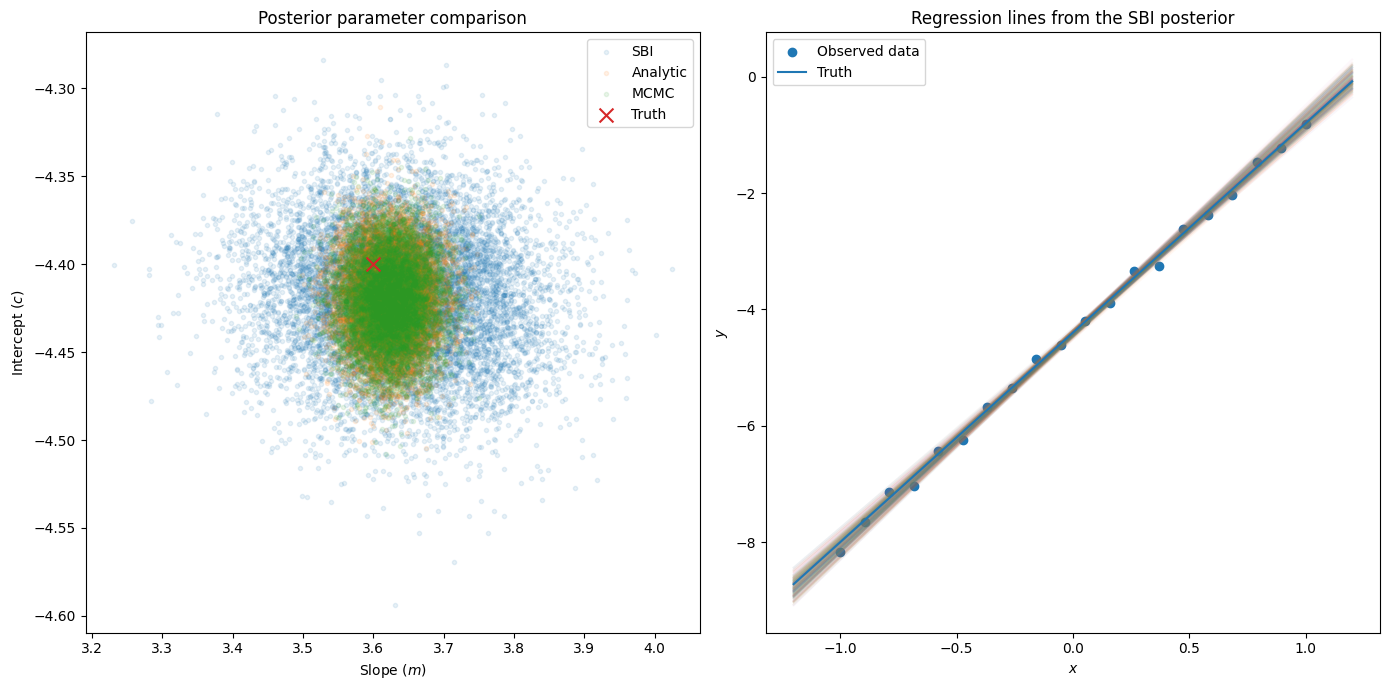

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=/Users/kattheod/Documents/py4e/StatMeth/sbi-logs/NPE_C/2026-09-24T14_59_29.027583' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


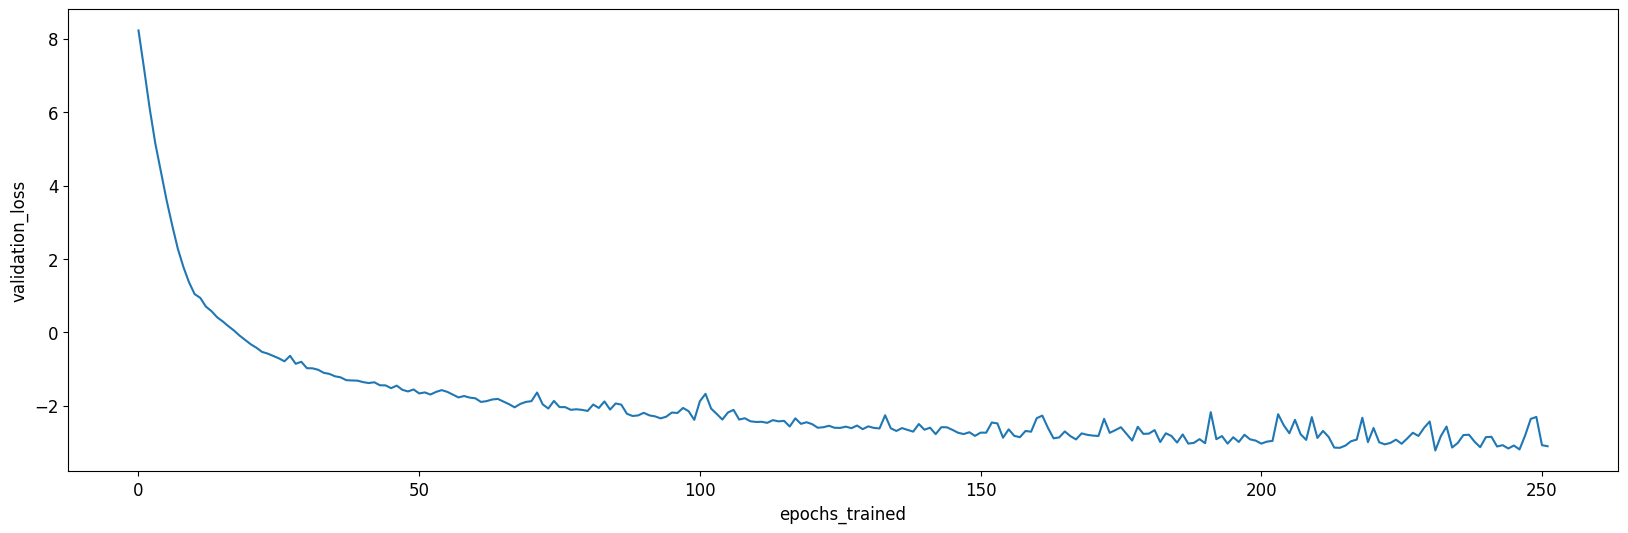

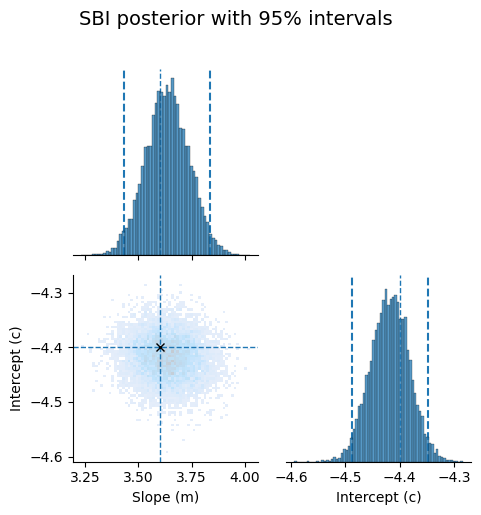

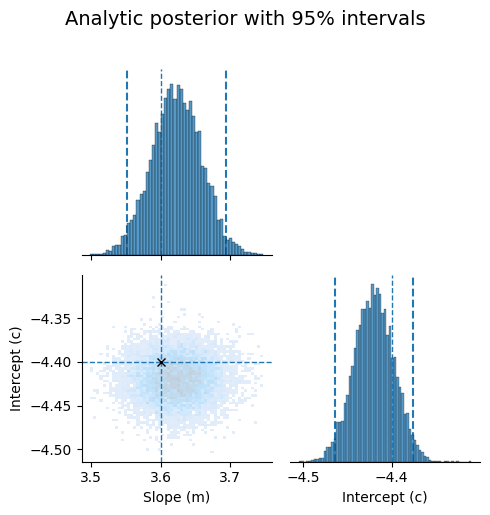

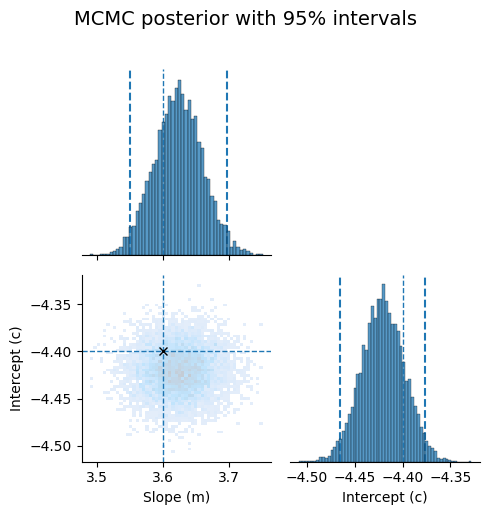

In [10]:
baseline = run_experiment()


Increasing the noise makes the observations less informative about the parameters. We compare the baseline with a substantially noisier dataset.

  0%|          | 0/2000 [00:00<?, ?it/s]

 Neural network successfully converged after 49 epochs.

  0%|          | 0/10000 [00:00<?, ?it/s]

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [m, c]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.


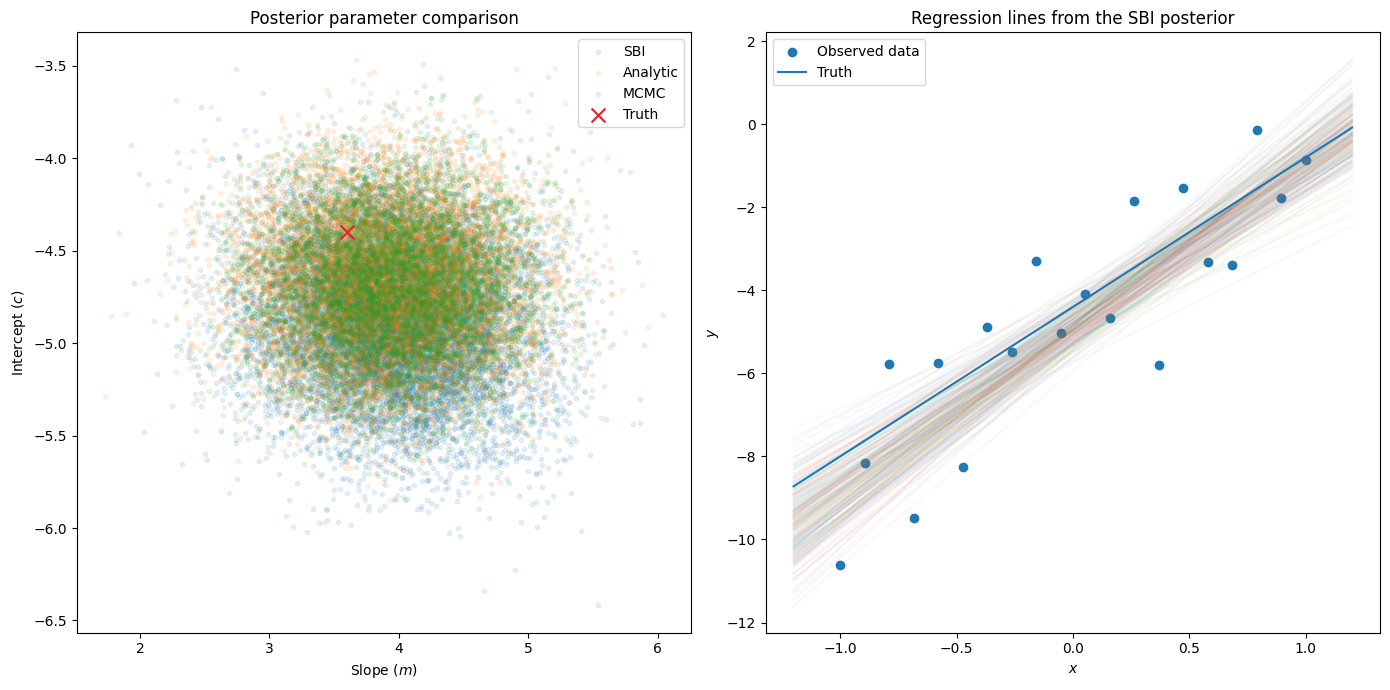

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=/Users/kattheod/Documents/py4e/StatMeth/sbi-logs/NPE_C/2026-09-24T15_03_44.676009' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


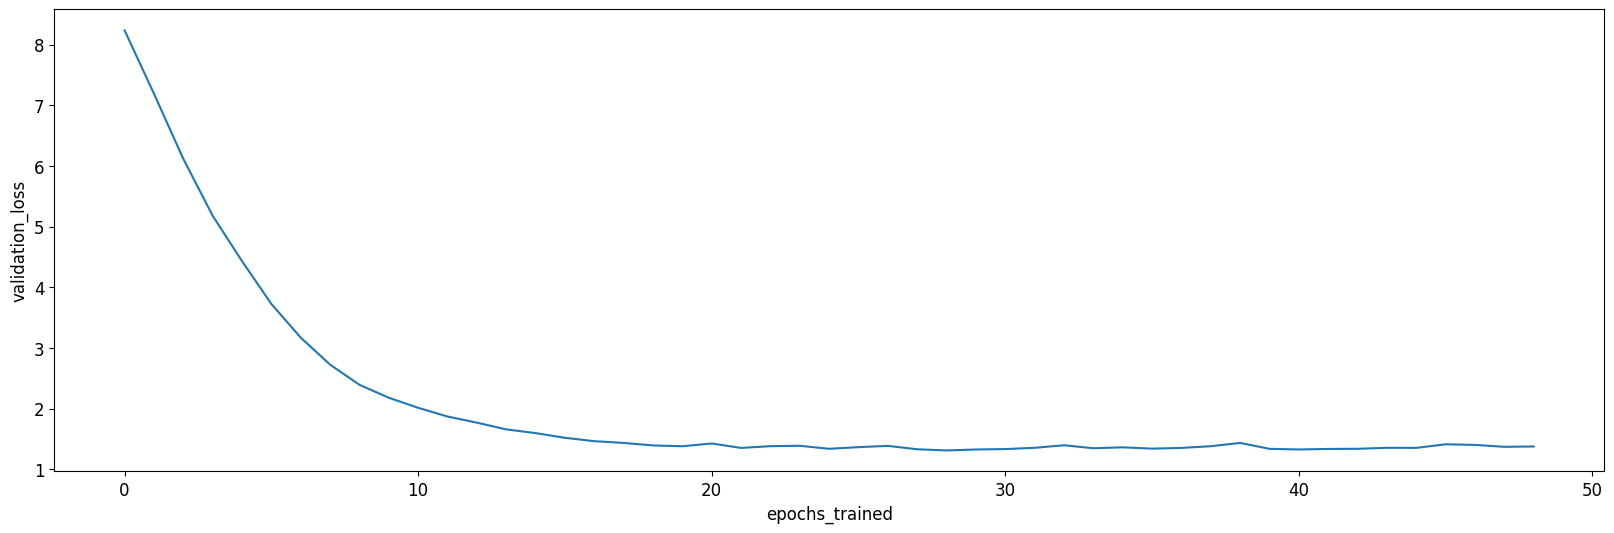

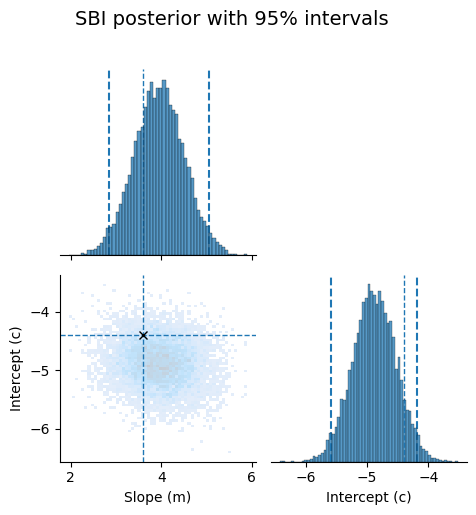

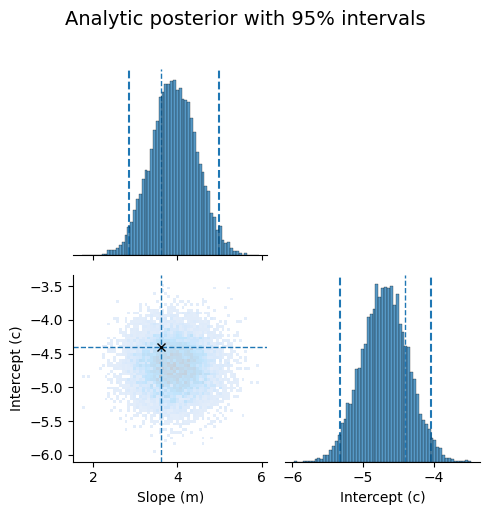

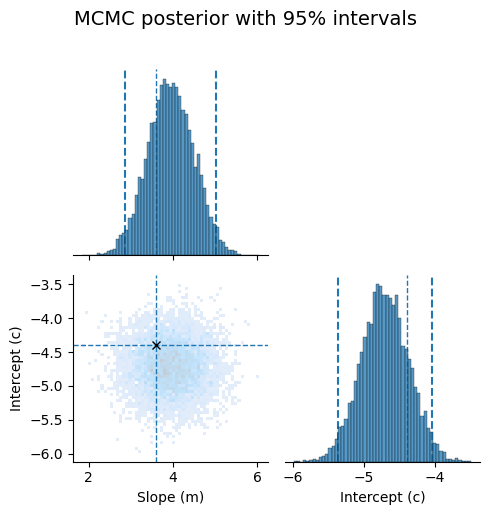

In [11]:
high_noise = run_experiment(
    sigma_noise=1.5,
)


Here the noise is very small, but only five observations are available. This illustrates how the amount and quality of information in the observations affect the posterior.

  0%|          | 0/2000 [00:00<?, ?it/s]

 Neural network successfully converged after 232 epochs.

  0%|          | 0/10000 [00:00<?, ?it/s]

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [m, c]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 4 seconds.


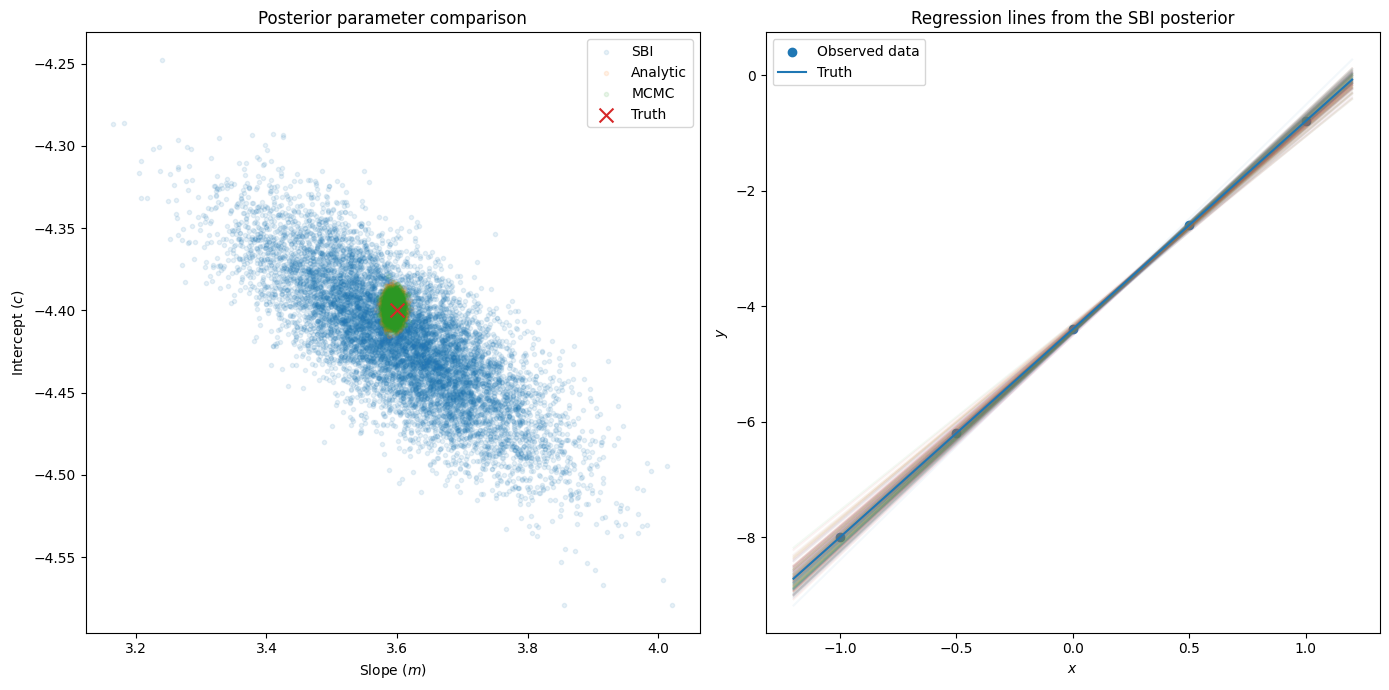

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=/Users/kattheod/Documents/py4e/StatMeth/sbi-logs/NPE_C/2026-09-24T15_04_14.038045' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


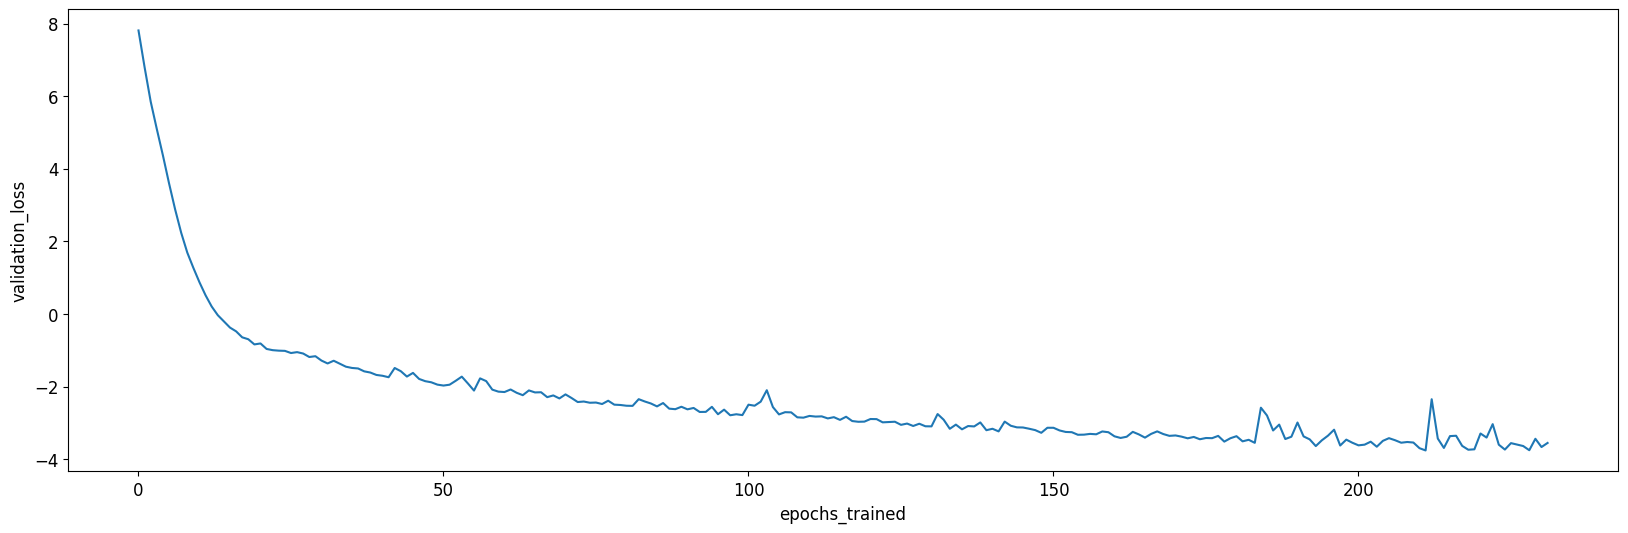

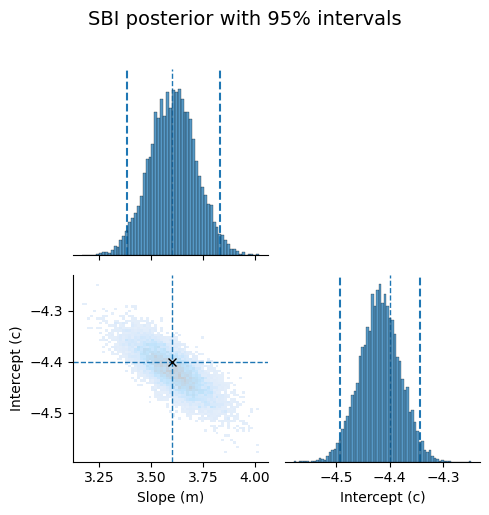

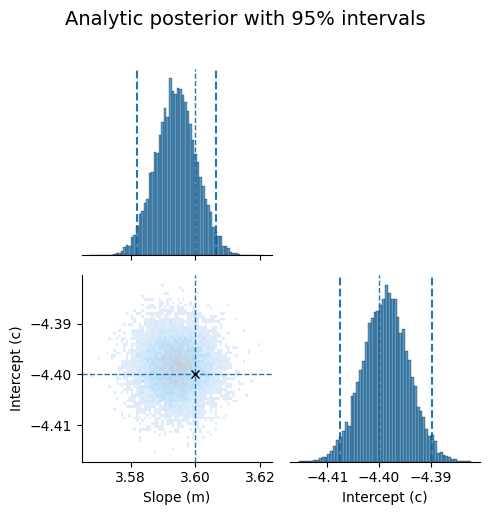

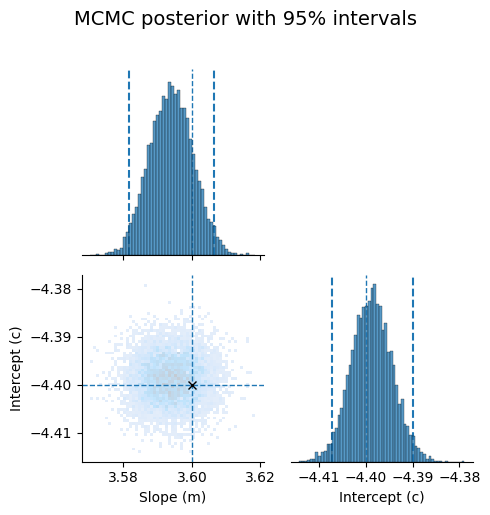

In [12]:
low_noise_sparse = run_experiment(
    sigma_noise=0.01,
    n_grid=5,
)

  0%|          | 0/100 [00:00<?, ?it/s]

 Neural network successfully converged after 117 epochs.

  0%|          | 0/10000 [00:00<?, ?it/s]

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [m, c]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.


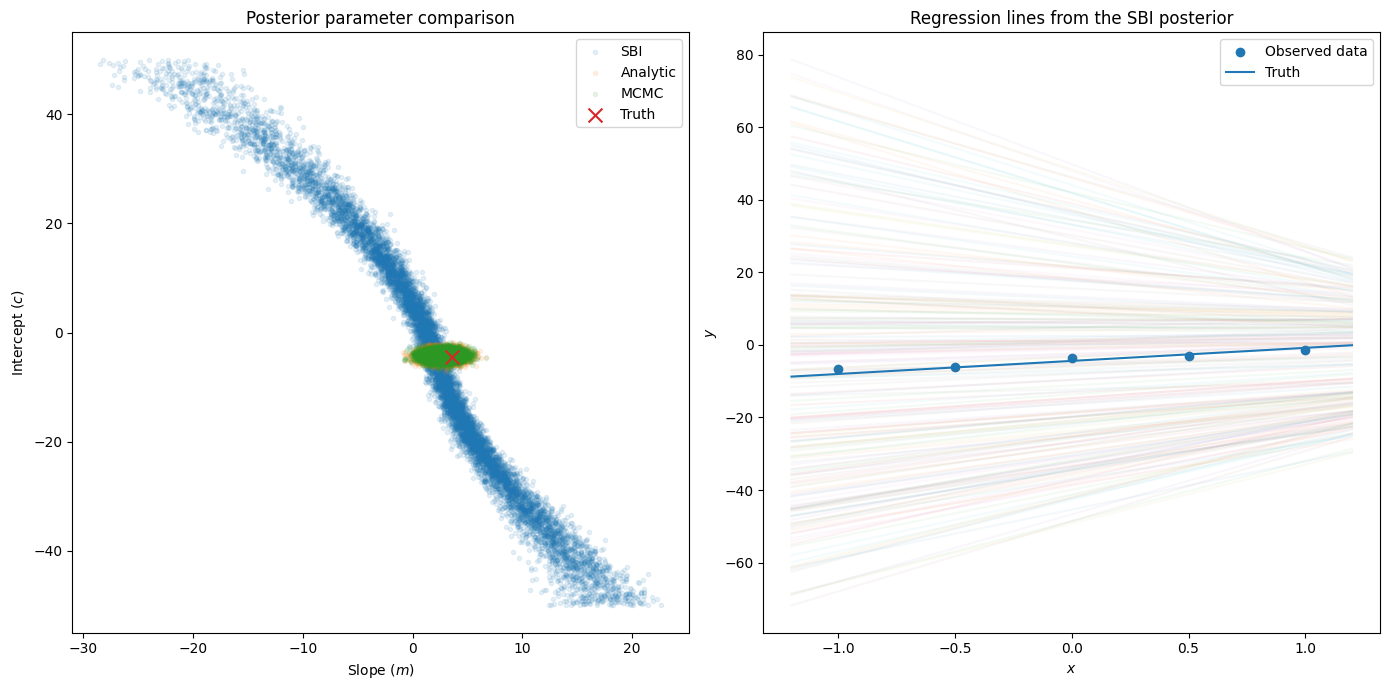

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=/Users/kattheod/Documents/py4e/StatMeth/sbi-logs/NPE_C/2026-09-24T15_07_51.574851' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


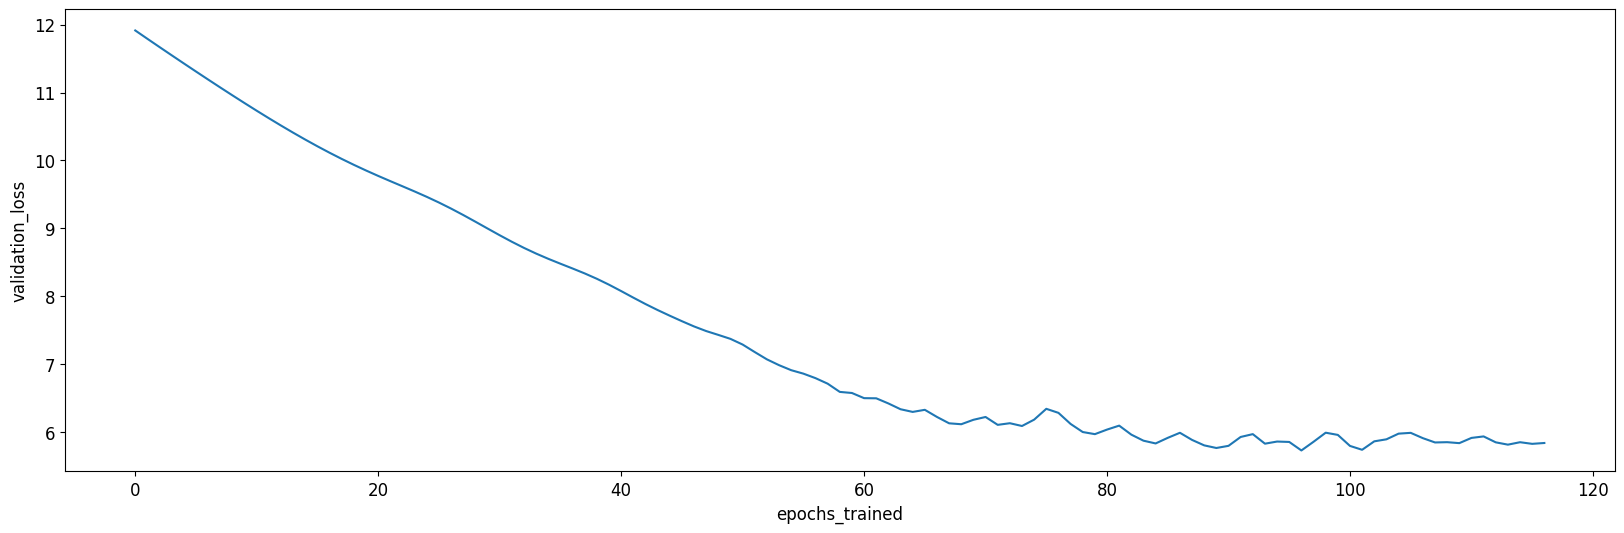

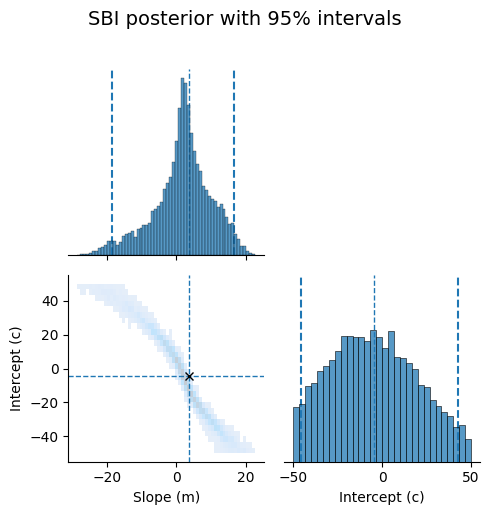

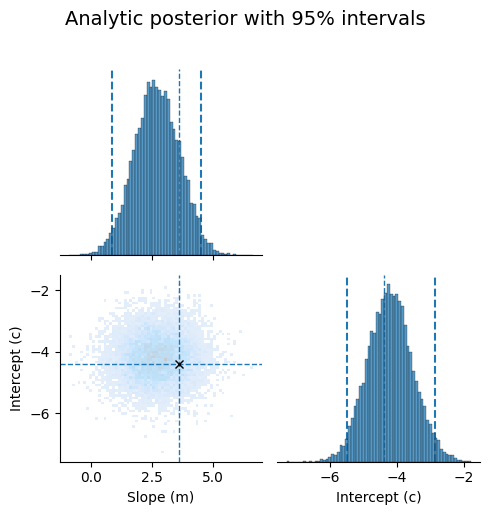

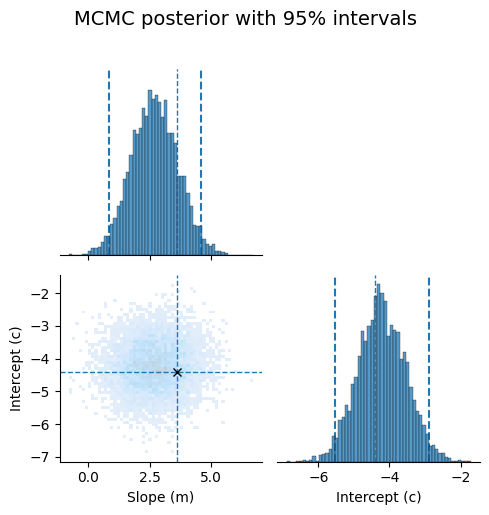

In [13]:
challenging = run_experiment(
    theta_true=torch.tensor([3.6, -4.4]),
    sigma_noise=1.5,
    n_grid=5,
    x_domain=(-1.0, 1.0),
    prior_bounds=(-50.0, 50.0),
    num_simulations=100,
    num_posterior_samples=10000,
    plot=True,
)


We reduce the number of observations while increasing the range of the independent variable. This changes the information available for estimating the slope and intercept.

  0%|          | 0/2000 [00:00<?, ?it/s]

 Neural network successfully converged after 378 epochs.

  0%|          | 0/10000 [00:00<?, ?it/s]

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [m, c]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.


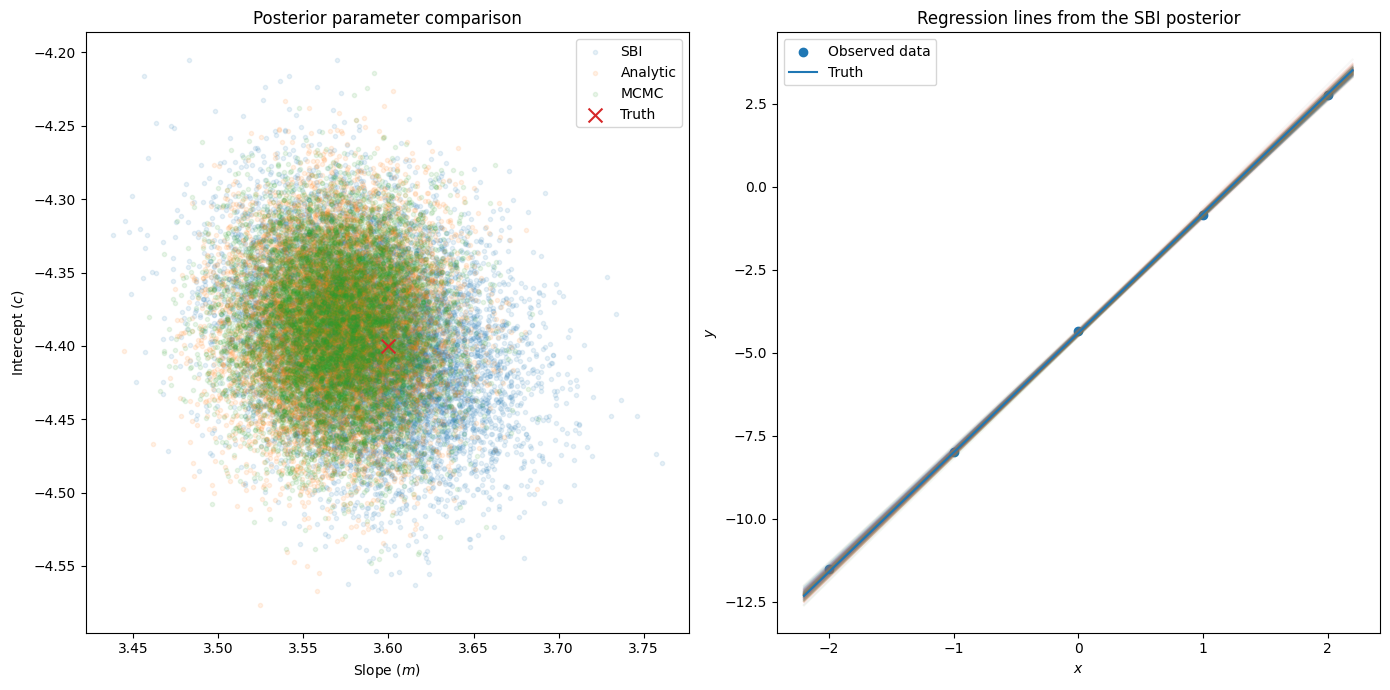

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=/Users/kattheod/Documents/py4e/StatMeth/sbi-logs/NPE_C/2026-09-24T15_08_48.271794' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


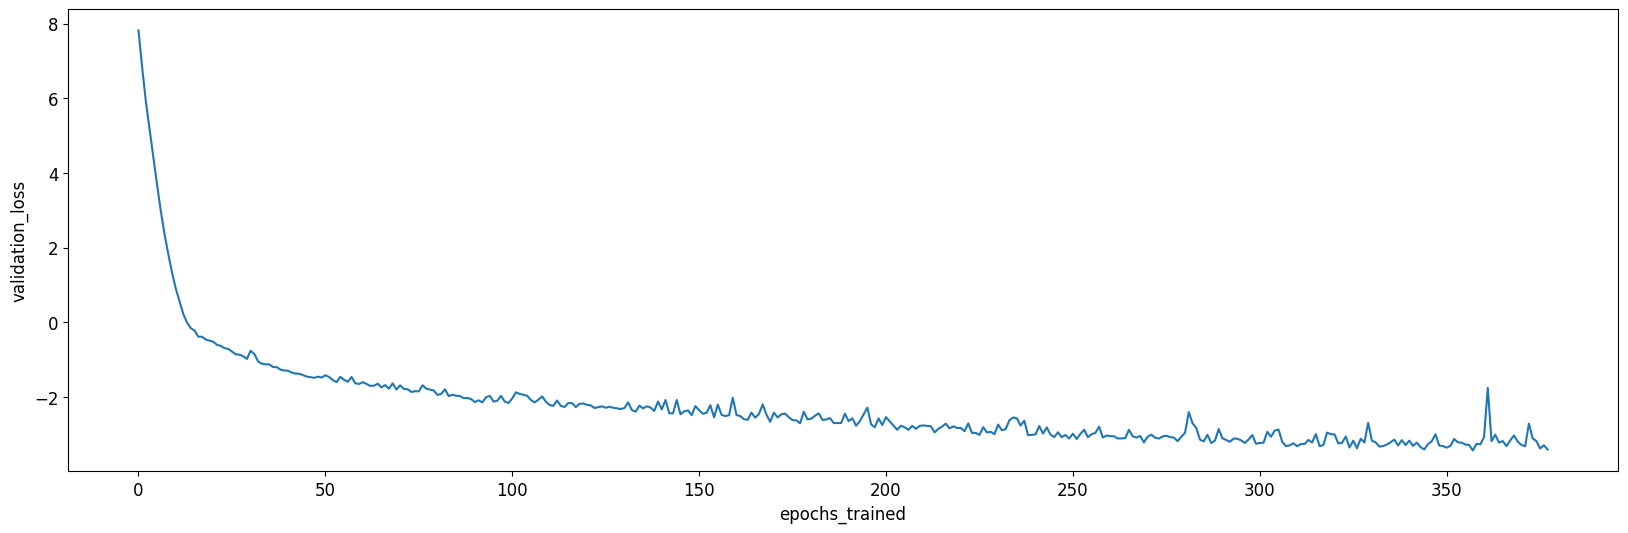

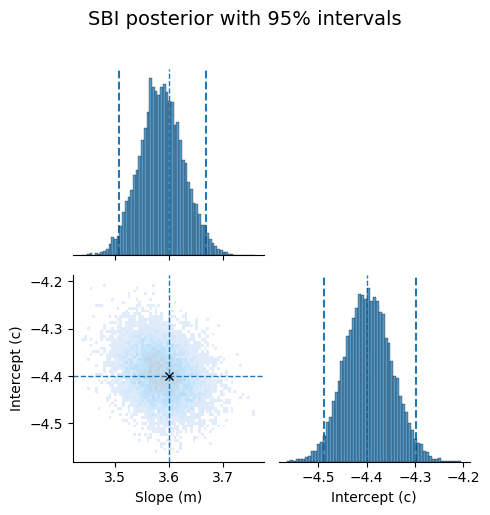

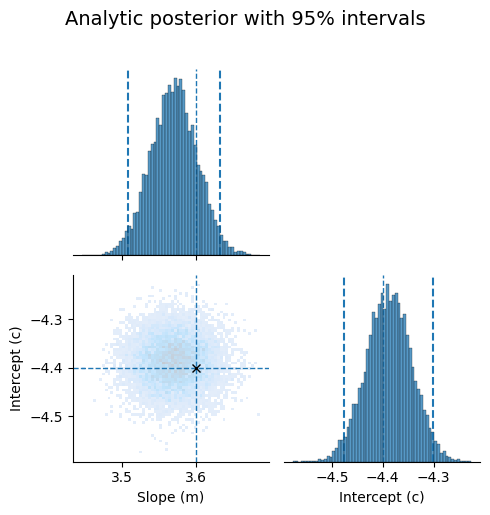

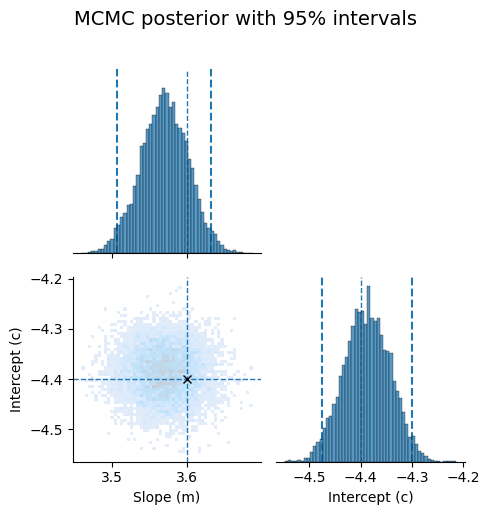

In [14]:
sparse_wide_range = run_experiment(
    n_grid=5,
    x_domain=(-2, 2),
)


Finally, we use a narrower and asymmetric prior. This shows how the assumed prior range can influence the inferred posterior, particularly when the data are not sufficiently informative to dominate the prior.

  0%|          | 0/2000 [00:00<?, ?it/s]

 Neural network successfully converged after 237 epochs.

  0%|          | 0/10000 [00:00<?, ?it/s]

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [m, c]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 6 seconds.


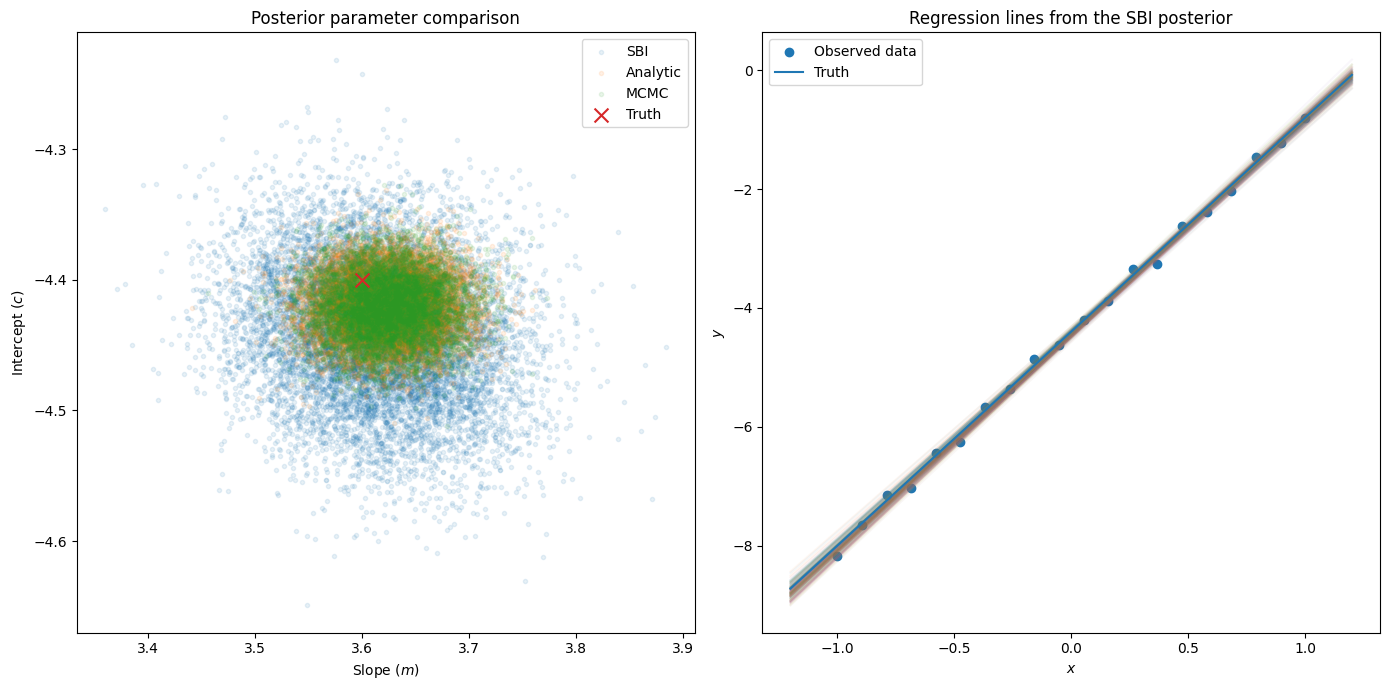

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=/Users/kattheod/Documents/py4e/StatMeth/sbi-logs/NPE_C/2026-09-24T15_09_32.392263' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


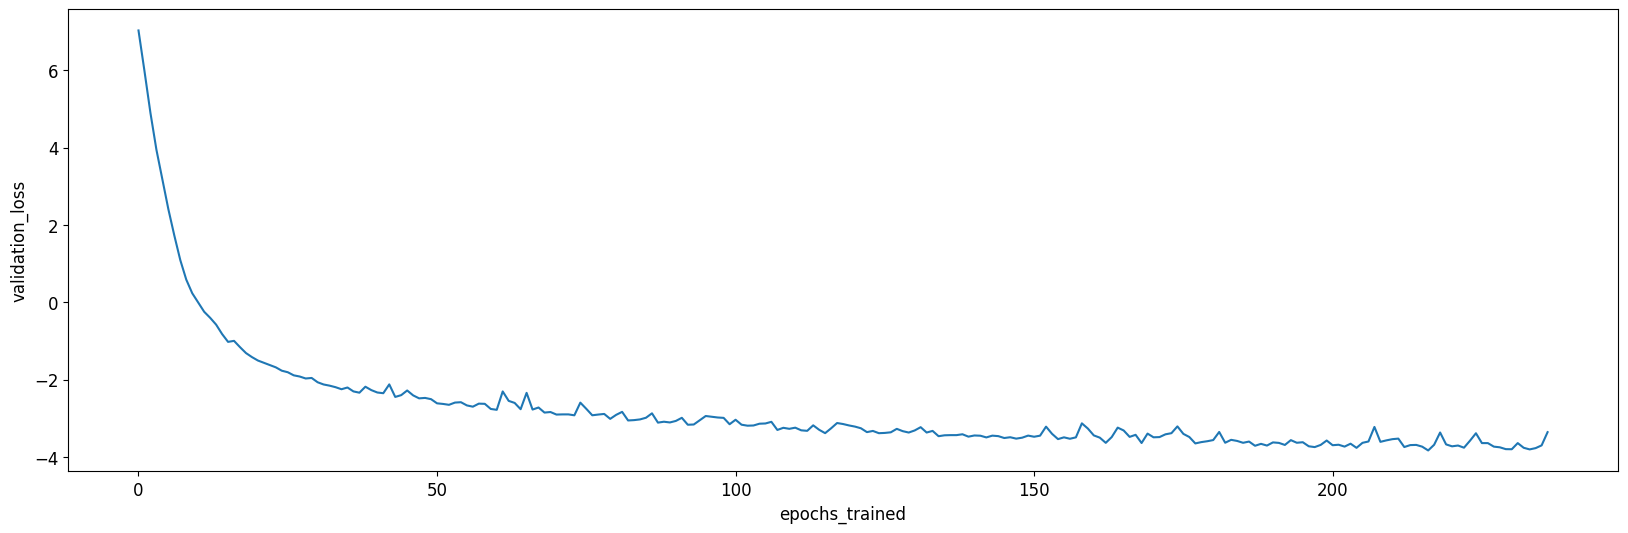

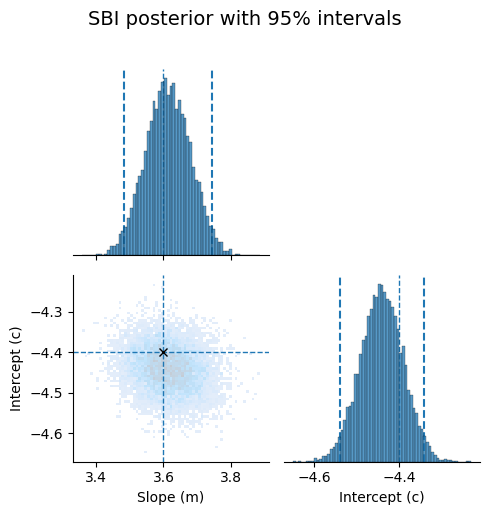

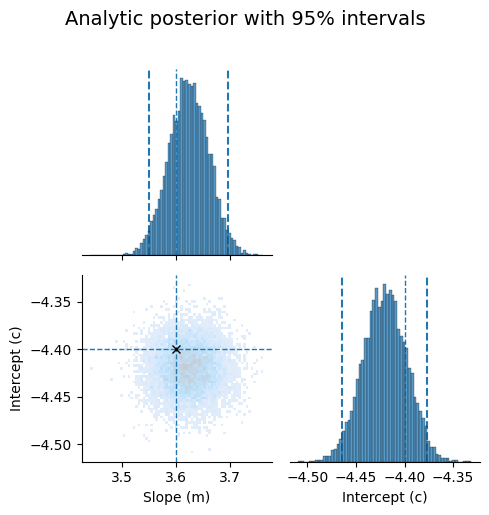

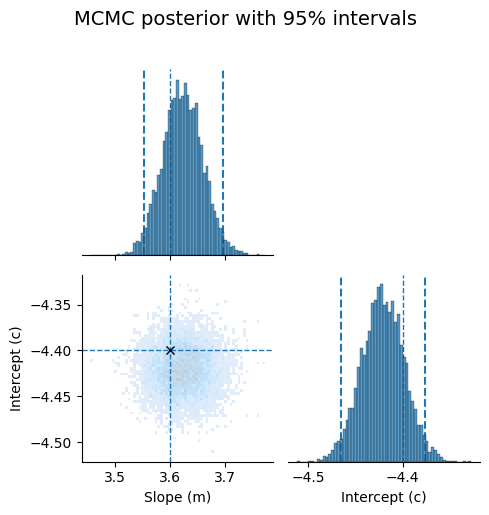

In [15]:
asymmetric_prior = run_experiment(
    prior_bounds=(-5.0, 6.0),
)

## Summary

The linear-regression example provides a controlled setting for comparing SBI with two reference approaches.

The experiments vary:

- observational noise,
- number and range of observations,
- prior bounds, and
- number of simulations used to train the SBI estimator.

Because the true parameters are known, the posterior samples can be directly compared with the ground truth as well as with the analytic and MCMC solutions.